In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, log_loss, f1_score, precision_score, recall_score, roc_curve, roc_auc_score, auc
from sklearn.model_selection import  GridSearchCV, cross_val_score, StratifiedKFold, learning_curve


In [23]:
df=pd.read_csv(r'C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\Datos\df_ransomware1.csv')

In [24]:
code = {False:0, True:1}
df['label'] = df['label'].map(code)
df.to_csv(r'C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\Datos\df_ransomware2.csv', index=False)
y = df['label']
X = df.drop(['label','year','day'],errors='ignore',axis=1)

In [25]:
features = X
#convertir la columna de direcciones (categórica) a enteros
cat_types = ['bool','object','category']

X[features.select_dtypes(cat_types).columns] = features.select_dtypes(cat_types).apply(lambda x: x.astype('category'))
features['address_code']=features['address'].cat.codes
code_address= features.select_dtypes(exclude=['int64', 'float64'])
features = features.drop('address',errors='ignore',axis=1)


In [27]:
#num_cols = X.select_dtypes(include=['int64', 'float64'])
#num_cols = num_cols.drop('year',errors='ignore',axis=1)
# Crear objeto StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Estandarizar features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)


In [6]:

# Crear secuencias temporales
def create_sequences(data, target, time_steps):
    X, y = [], []

    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(target[i+time_steps])
    return np.array(X), np.array(y)

time_steps = 12  # Ejemplo: ventanas de 12 meses
X, y = create_sequences(scaled_features, df["label"].values, time_steps)


# Dividir datos
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=123)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=123)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Para clasificación binaria
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72918/72918 ━━━━━━━━━━━━━━━━━━━━ 837s 11ms/step - accuracy: 0.9968 - loss: 0.0158 - val_accuracy: 1.0000 - val_loss: 1.5248e-04
Epoch 2/20
72918/72918 ━━━━━━━━━━━━━━━━━━━━ 1163s 16ms/step - accuracy: 0.9999 - loss: 2.5003e-04 - val_accuracy: 1.0000 - val_loss: 1.7235e-04
Epoch 3/20
72918/72918 ━━━━━━━━━━━━━━━━━━━━ 1244s 17ms/step - accuracy: 1.0000 - loss: 1.5756e-04 - val_accuracy: 1.0000 - val_loss: 1.1325e-04
Epoch 4/20
72918/72918 ━━━━━━━━━━━━━━━━━━━━ 1093s 15ms/step - accuracy: 1.0000 - loss: 1.6777e-04 - val_accuracy: 1.0000 - val_loss: 3.2186e-05
Epoch 5/20
72918/72918 ━━━━━━━━━━━━━━━━━━━━ 1890s 26ms/step - accuracy: 1.0000 - loss: 9.9125e-05 - val_accuracy: 1.0000 - val_loss: 4.9057e-05
Epoch 6/20
72918/72918 ━━━━━━━━━━━━━━━━━━━━ 1861s 26ms/step - accuracy: 1.0000 - loss: 9.0228e-05 - val_accuracy: 1.0000 - val_loss: 8.0954e-05
Epoch 7/20
72918/72918 ━━━━━━━━━━━━━━━━━━━━ 674s 9ms/step - accuracy: 1.0000 - loss: 6.8805e-05 - val_accuracy: 1.0000 - val_loss: 4.8453e-05

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

9115/9115 ━━━━━━━━━━━━━━━━━━━━ 74s 8ms/step - accuracy: 1.0000 - loss: 8.2049e-06
Test Accuracy: 1.00


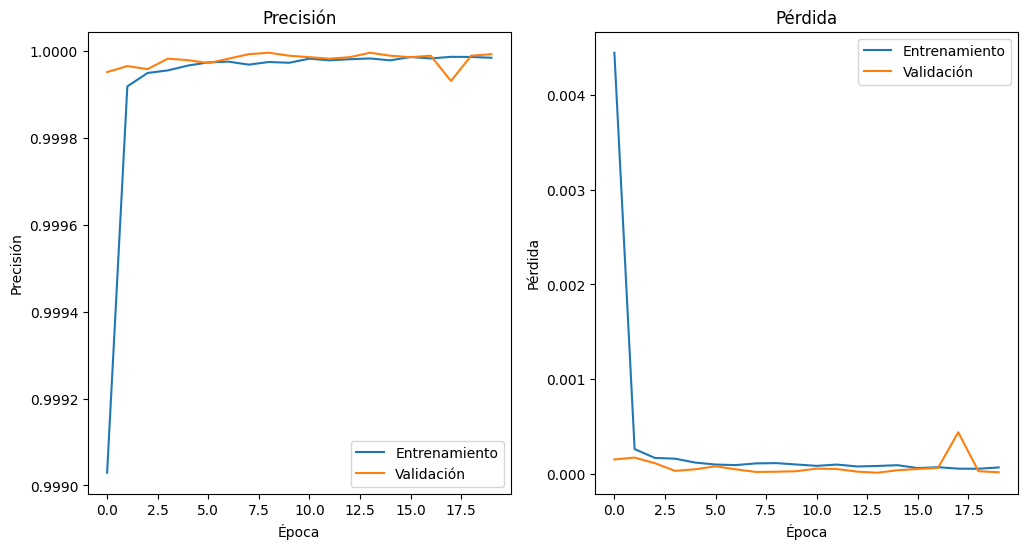

<Figure size 640x480 with 0 Axes>

In [10]:
# Graficar la precisión y la pérdida
plt.figure(figsize=(12, 6))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\perdida_precision.pdf", format='pdf')

In [11]:
from sklearn.metrics import  classification_report, confusion_matrix

# Predicciones en los datos de prueba
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Convertir probabilidades en etiquetas

# Reporte de clasificación
print(classification_report(y_test, y_pred))

# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

9115/9115 ━━━━━━━━━━━━━━━━━━━━ 74s 8ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    287520
           1       1.00      1.00      1.00      4149

    accuracy                           1.00    291669
   macro avg       1.00      1.00      1.00    291669
weighted avg       1.00      1.00      1.00    291669

[[287519      1]
 [     0   4149]]


9115/9115 ━━━━━━━━━━━━━━━━━━━━ 68s 7ms/step


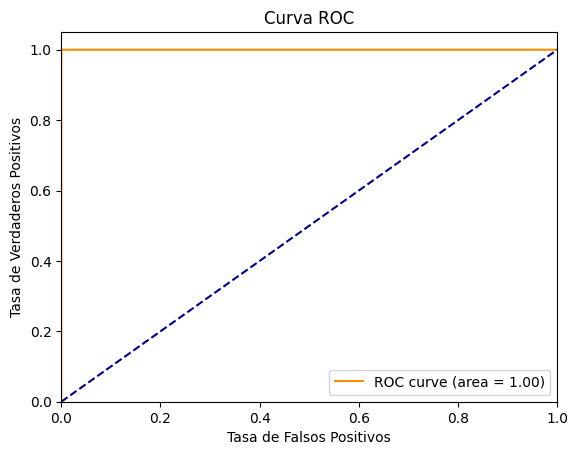

In [12]:
# Calcular la curva ROC
y_pred = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calcular el AUC
roc_auc = roc_auc_score(y_test, y_pred)

# Graficar la curva ROC
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\ROC_LSTM.pdf", format='pdf')

In [31]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=2346)
X_res, y_res = smote.fit_resample(scaled_features, y)


# Crear secuencias temporales
def create_sequences(data, target, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(target[i+time_steps])
    return np.array(X), np.array(y)

time_steps = 12  # Ejemplo: ventanas de 12 meses
X_res, y_res = create_sequences(X_res, y_res, time_steps)
X_res_train, X_res_temp, y_res_train, y_res_temp = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
X_val, X_res_test, y_val, y_res_test = train_test_split(X_res_temp, y_res_temp, test_size=0.5, random_state=42)

In [32]:
model_1 = Sequential([
    LSTM(64, input_shape=(X_res_train.shape[1], X_res_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Para clasificación binaria
])

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_1.summary()

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history_1 = model_1.fit(
    X_res_train, y_res_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
143764/143764 ━━━━━━━━━━━━━━━━━━━━ 2133s 15ms/step - accuracy: 0.8304 - loss: 0.3660 - val_accuracy: 0.9319 - val_loss: 0.1810
Epoch 2/20
143764/143764 ━━━━━━━━━━━━━━━━━━━━ 1902s 13ms/step - accuracy: 0.9277 - loss: 0.1846 - val_accuracy: 0.9392 - val_loss: 0.1580
Epoch 3/20
143764/143764 ━━━━━━━━━━━━━━━━━━━━ 1790s 12ms/step - accuracy: 0.9452 - loss: 0.1451 - val_accuracy: 0.9509 - val_loss: 0.1284
Epoch 4/20
143764/143764 ━━━━━━━━━━━━━━━━━━━━ 1479s 10ms/step - accuracy: 0.9536 - loss: 0.1245 - val_accuracy: 0.9517 - val_loss: 0.1254
Epoch 5/20
143764/143764 ━━━━━━━━━━━━━━━━━━━━ 1799s 13ms/step - accuracy: 0.9577 - loss: 0.1141 - val_accuracy: 0.9628 - val_loss: 0.1002
Epoch 6/20
143764/143764 ━━━━━━━━━━━━━━━━━━━━ 1597s 11ms/step - accuracy: 0.9605 - loss: 0.1070 - val_accuracy: 0.9634 - val_loss: 0.0978
Epoch 7/20
143764/143764 ━━━━━━━━━━━━━━━━━━━━ 1902s 13ms/step - accuracy: 0.9628 - loss: 0.1008 - val_accuracy: 0.9659 - val_loss: 0.0929
Epoch 8/20
143764/143764 ━━━━━━━━━

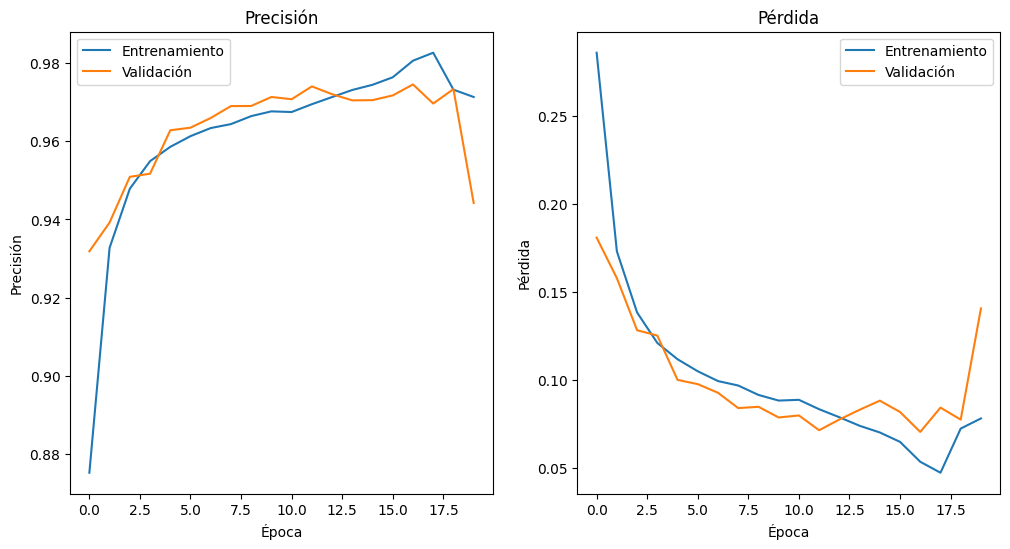

<Figure size 640x480 with 0 Axes>

In [34]:
# Graficar la precisión y la pérdida
plt.figure(figsize=(12, 6))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='Entrenamiento')
plt.plot(history_1.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Entrenamiento')
plt.plot(history_1.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\perdida_precision_balanceado.pdf", format='pdf')

In [38]:
# Predicciones en los datos de prueba
y_res_pred = model_1.predict(X_res_test)
y_res_pred = (y_res_pred > 0.5).astype(int)  # Convertir probabilidades en etiquetas

# Reporte de clasificación
print(classification_report(y_res_test, y_res_pred))

# Matriz de confusión
print(confusion_matrix(y_res_test, y_res_pred))

17971/17971 ━━━━━━━━━━━━━━━━━━━━ 67s 4ms/step
              precision    recall  f1-score   support

           0       0.98      0.91      0.94    287539
           1       0.91      0.98      0.95    287517

    accuracy                           0.94    575056
   macro avg       0.95      0.94      0.94    575056
weighted avg       0.95      0.94      0.94    575056

[[260723  26816]
 [  5246 282271]]
